# Home Credit Default Risk - EDA

> **Dataset:** `application_train.csv` from the [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) competition.
>
> **Goal:** Explore the data to understand class imbalance, missing values, and which features correlate with `TARGET` (1 = client defaulted on their loan, 0 = paid it back), ahead of building a predictive model.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('application_train.csv')
df.shape

(307511, 122)

In [31]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [33]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

#### Check imbalance
> See how skewed TARGET is between defaulters and non-defaulters

In [34]:
df['TARGET'].value_counts(normalize=True) # 91.9% Paid back their loan, 8.1% didnt

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Text(0, 0.5, 'Count')

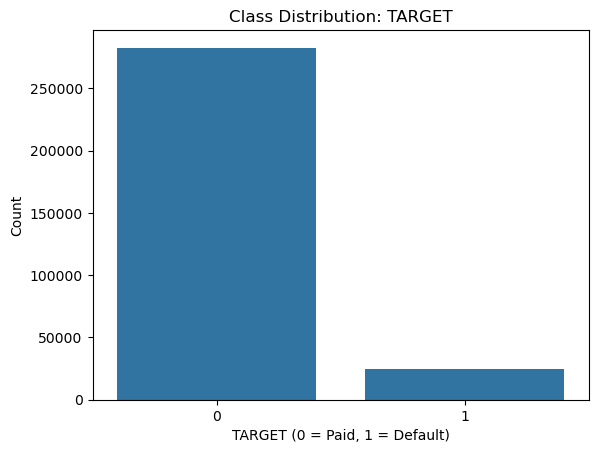

In [35]:
sns.countplot(x='TARGET', data=df)
plt.title('Class Distribution: TARGET')
plt.xlabel('TARGET (0 = Paid, 1 = Default)')
plt.ylabel('Count')

#### Imbalance

> With almost 92% of people who paid back their loan, 8% did not which is a huge imbalance. 
>
> This imbalance could hurt the model **During Training** as it will see high **non-defaulters**, so it will learn to just predict 0 every time.
> 
> **During Testing** if we just go off accuracy, 92% would sound great but the model is useless as it just ignored the **Defaulters**
>
> To handle this imbalance we will go off metrics such as
- Recall - High recall means we catch more defaulters but we'll also flag more false positives.
- ROC-AUC (Receiver Operating Characteristic - Area Under Curve) - Plots the tradeoff at every threshold. A score of 0.5 is random guessing, 0.8+ is good. More honest than accuracy on imbalanced data.
>
> **Business Context:** - A bank would rather flag someone who would have paid then miss someone who's going to default


#### Find missing values
> Identify how much data is missing per column, to decide which columns are worth keeping vs. dropping before imputation

In [36]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64


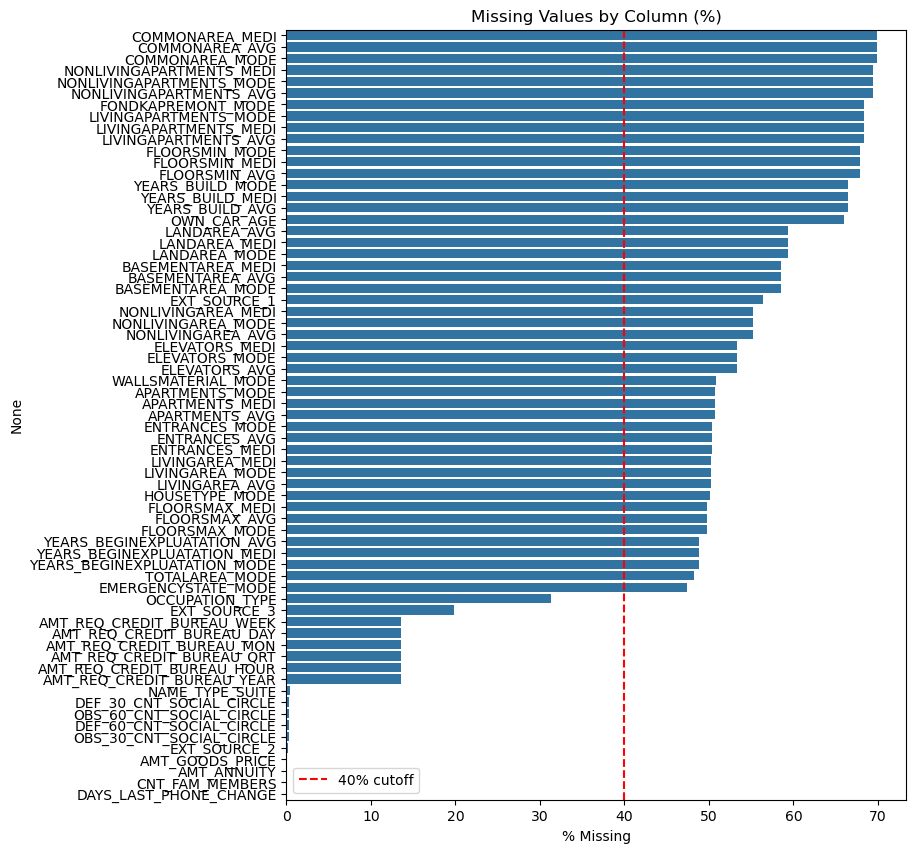

In [37]:
plt.figure(figsize=(8, 10))
sns.barplot(x=missing.values, y=missing.index)
plt.axvline(40, color='red', linestyle='--', label='40% cutoff')
plt.title('Missing Values by Column (%)')
plt.xlabel('% Missing')
plt.legend()
plt.show()

In [38]:
drop_cols = missing[missing > 40].index.tolist()
print(f"Columns to drop: {len(drop_cols)}")
print(drop_cols)

keep_cols = [c for c in df.columns if c not in drop_cols]
print(f"Columns kept: {len(keep_cols)}")
print(keep_cols)


Columns to drop: 49
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG', 'HOUSETYPE_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE', 

#### Missing data
> Columns with more than 40% missing values (`drop_cols`) are strong *candidates* to drop, since imputing that much data would likely introduce more noise than signal — but that needs to be checked against each column's relationship with TARGET before actually dropping anything.
>
> 67 out of 122 columns had missing data. 49 of those have more than 40% missing (`drop_cols`); the remaining 73 columns (`keep_cols`) have little enough missing data to keep as-is for now.
>
> **No columns have been dropped from `df` yet.** Before finalizing `drop_cols`, I checked each candidate column's correlation with TARGET below — a column with real predictive signal might be worth keeping (e.g. via a dedicated imputation strategy) even with high missingness.

In [39]:
for col in drop_cols:
    if df[col].dtype in ['float64', 'int64']:
        non_null = df[[col, 'TARGET']].dropna()
        corr = non_null[col].corr(non_null['TARGET'])
        print(f"{col}: corr = {corr:.4f}, n = {len(non_null)}")
    else:
        print(f"{col}: (categorical — skipped, check separately via group-by mean)")

COMMONAREA_MEDI: corr = -0.0186, n = 92646
COMMONAREA_AVG: corr = -0.0185, n = 92646
COMMONAREA_MODE: corr = -0.0163, n = 92646
NONLIVINGAPARTMENTS_MEDI: corr = -0.0028, n = 93997
NONLIVINGAPARTMENTS_MODE: corr = -0.0016, n = 93997
NONLIVINGAPARTMENTS_AVG: corr = -0.0032, n = 93997
FONDKAPREMONT_MODE: (categorical — skipped, check separately via group-by mean)
LIVINGAPARTMENTS_MODE: corr = -0.0234, n = 97312
LIVINGAPARTMENTS_MEDI: corr = -0.0246, n = 97312
LIVINGAPARTMENTS_AVG: corr = -0.0250, n = 97312
FLOORSMIN_MODE: corr = -0.0327, n = 98869
FLOORSMIN_MEDI: corr = -0.0334, n = 98869
FLOORSMIN_AVG: corr = -0.0336, n = 98869
YEARS_BUILD_MODE: corr = -0.0221, n = 103023
YEARS_BUILD_MEDI: corr = -0.0223, n = 103023
YEARS_BUILD_AVG: corr = -0.0221, n = 103023
OWN_CAR_AGE: corr = 0.0376, n = 104582
LANDAREA_AVG: corr = -0.0109, n = 124921
LANDAREA_MEDI: corr = -0.0113, n = 124921
LANDAREA_MODE: corr = -0.0102, n = 124921
BASEMENTAREA_MEDI: corr = -0.0221, n = 127568
BASEMENTAREA_AVG: corr

#### Correlation check on `drop_cols` (before finalizing)
> Before dropping the 49 `drop_cols` columns, I checked whether any of them actually carry signal for TARGET despite being >40% missing.
>
> **`EXT_SOURCE_1` stands out** — correlation of **-0.1553** (n=134,133), on par with `EXT_SOURCE_2` (-0.1605) and `EXT_SOURCE_3` (-0.1789), the two strongest predictors in the whole dataset. That's too much signal to drop just because of missingness.
>
> Every other numeric column in `drop_cols` has |corr| < 0.05 (mostly building/apartment quality features — `COMMONAREA_*`, `LIVINGAREA_*`, `ELEVATORS_*`, `FLOORSMAX_*`, etc.) — weak linear relationships with TARGET individually, consistent with dropping.
>
> The 4 categorical columns in `drop_cols` (`FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`, `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE`) were skipped here since Pearson correlation doesn't apply to them directly. The group-by mean check earlier (in the non-numeric TARGET relationship section) shows their category-level default rates staying in a similar band (roughly 5–10%), with no standout signal like `EXT_SOURCE_1`'s.
>
> **Conclusion:** `EXT_SOURCE_1` should be pulled out of the drop list. Everything else in `drop_cols` still looks safe to drop on the missingness rule — pending final review.

In [40]:
flagged_cols = ['EXT_SOURCE_1']  # strong TARGET correlation despite >40% missing — keep for now

final_drop_cols = [c for c in drop_cols if c not in flagged_cols]
print(f"Reviewed columns to drop: {len(final_drop_cols)} (was {len(drop_cols)})")
print(final_drop_cols)

# NOTE: this is still just a candidate list — no df.drop() has been run yet.

Reviewed columns to drop: 48 (was 49)
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG', 'HOUSETYPE_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE'

#### Correlation
> Find correlation between TARGET and other features

In [41]:
corr = df.corr(numeric_only=True)['TARGET'].sort_values()
print(corr)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
                                 ...   
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, Length: 106, dtype: float64


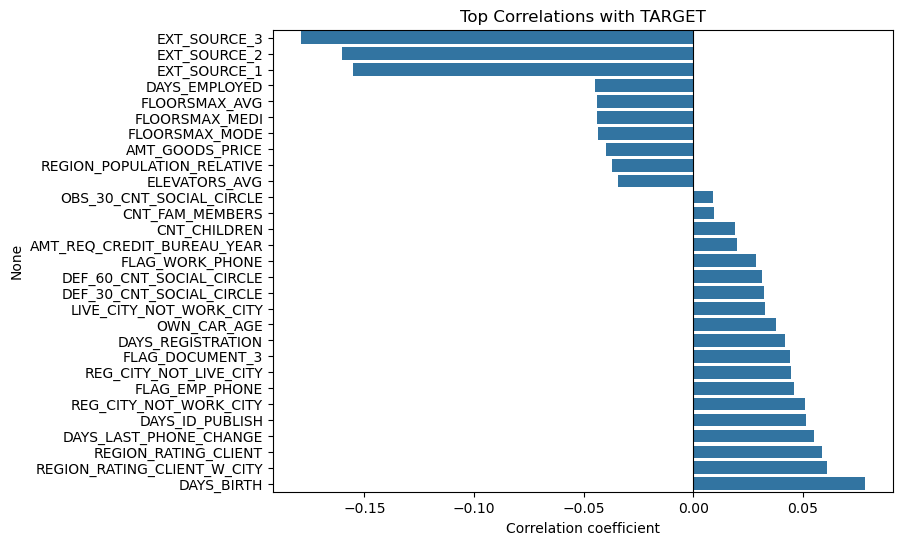

In [42]:
top_corr = pd.concat(([corr.head(10), corr.tail(20)]))
top_corr = top_corr.drop('TARGET')

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top Correlations with TARGET')
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)

#### Correlation Summary
>
> As EXT_SOURCE_3/2/1 decrease, TARGET tends to increase (more likely to default)
>
> As EXT_SOURCE_3/2/1 increases, TARGET tends to decrease (less likely to default)
> 
> As DAYS_BIRTH increases, TARGET increases (more likely to default)
>
> As DAYS_BIRTH decreases, TARGET decreases (more likely to default)

#### Check non-numerical values relationship with TARGET
> Earlier, I checked the correlation between TARGET and numeric columns only. Before feature dropping and handling missing values I will check how TARGET's default rate varies across non-numeric categories using groupby.

In [43]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"--- {col} ---")
    summary = df.groupby(col)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(summary)
    print()


--- NAME_CONTRACT_TYPE ---
                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083459  278232
Revolving loans     0.054783   29279

--- CODE_GENDER ---
                 mean   count
CODE_GENDER                  
M            0.101419  105059
F            0.069993  202448
XNA          0.000000       4

--- FLAG_OWN_CAR ---
                  mean   count
FLAG_OWN_CAR                  
N             0.085002  202924
Y             0.072437  104587

--- FLAG_OWN_REALTY ---
                     mean   count
FLAG_OWN_REALTY                  
N                0.083249   94199
Y                0.079616  213312

--- NAME_TYPE_SUITE ---
                     mean   count
NAME_TYPE_SUITE                  
Other_B          0.098305    1770
Other_A          0.087760     866
Group of people  0.084871     271
Unaccompanied    0.081830  248526
Spouse, partner  0.078716   11370
Family           0.074946   40149
Children         0.073768    3267

--- NAME_INCOME

In [44]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [45]:
df['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [46]:
df[df['ORGANIZATION_TYPE'] == 'XNA']['NAME_INCOME_TYPE'].value_counts() # find XNA between ORGANIZATION_TYPE and how they get their income

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

#### "Weird Values"
> Only 4 **XNA** in **CODE_GENDER**, we'll ignore since this wont affect the model
>
> With 55,374 **XNA**'s in **ORGANIZATION_TYPE** I found out that 55,352 are **Pensioner** and 22 are **Unemployed**
>
> This confirms XNA here isnt missing/broken data - its just expected, since Pensioners and the Unemployed don't have an organization to report. I'll keep it as its own valid category rather than imputing or dropping these rows

#### Investigating EXT_SOURCE_1


In [47]:
# Wherever missing_mask = True, EXT_SOURCE_1 is null
missing_mask = df['EXT_SOURCE_1'].isnull()

# Does missingness correlate with income type?
print(df[missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True))

NAME_INCOME_TYPE
Working                 0.487115
Pensioner               0.245198
Commercial associate    0.205908
State servant           0.061600
Unemployed              0.000087
Student                 0.000052
Businessman             0.000035
Maternity leave         0.000006
Name: proportion, dtype: float64


In [48]:
# Wherever missing_mask = False, EXT_SOURCE_1 is non-null
print(df[~missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True))

NAME_INCOME_TYPE
Working                 0.554069
Commercial associate    0.267772
Pensioner               0.095800
State servant           0.082180
Student                 0.000067
Unemployed              0.000052
Maternity leave         0.000030
Businessman             0.000030
Name: proportion, dtype: float64


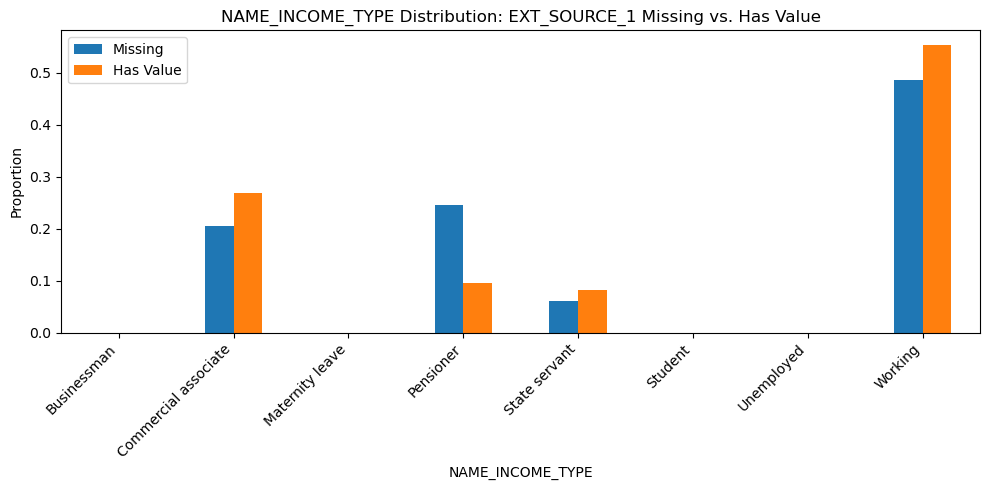

In [50]:
missing_props = df[missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)
nonmissing_props = df[~missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

compare_df = pd.DataFrame({'Missing': missing_props, 'Has Value': nonmissing_props}).fillna(0)
compare_df.plot(kind='bar', figsize=(10,5))
plt.title('NAME_INCOME_TYPE Distribution: EXT_SOURCE_1 Missing vs. Has Value')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
df['EXT_SOURCE_1_missing'] = df['EXT_SOURCE_1'].isnull().astype(int)
print(df.groupby('EXT_SOURCE_1_missing')['TARGET'].mean())

EXT_SOURCE_1_missing
0    0.074955
1    0.085195
Name: TARGET, dtype: float64


#### EXT_SOURCE_1 Conclusion
> Missingness in EXT_SOURCE_1 is not random. Pensioners are disproportionately represented (~2.5x) in the missing group compared to the non-missing group, suggesting this external score may rely on data (e.g. active employment or credit history) that's less available for retirees. Checking the missingness flag directly against TARGET shows only a small difference in default rate (8.5% missing vs. 7.5% non-missing) — so while missingness is structurally non-random, it's a weak standalone predictor on its own. I'll keep the EXT_SOURCE_1_missing flag alongside imputed values, since it may still combine usefully with other features even though its direct effect is modest.